# Goal

1: Split Data into:
**Training Set(70%)
**Validation Set(15%)
**Test Set(15%)

<br>

2: Applying Logistic Regression and Evaluation

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd

#First splitting into 70% and 30%

x = pd.read_csv("../dataset/preprocessed_churn.csv")

y = pd.read_csv("../dataset/target.csv").squeeze()  # Convert to Series
#Converted to series to avoid issues with shape during splitting
#As model expects 1D array for target variable

#We would not have needed to do this if we had done
#all of that in a single notebook, but since we are doing it in multiple notebooks, we need to save the preprocessed data and target variable separately and then load them here for splitting
#but when we saved target variable, we saved it as a dataframe, so we need to convert it to series before splitting
#If we had done all of this in a single notebook, we could have just kept it as a series and then we would not have needed to convert it back to series here

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

In [2]:
#Now splitting the remaining 30% into 15% and 15%

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print(x_train.shape, x_val.shape, x_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

#Now we have our training, validation, and test sets ready for model training and evaluation
#We move to the model training and evaluation step

(4930, 30) (1056, 30) (1057, 30)
(4930,) (1056,) (1057,)


In [4]:
#Logistic Regression

#importing the logistic regression model from sklearn
from sklearn.linear_model import LogisticRegression

#initializing the logistic regression model with a maximum of 1000 iterations to ensure convergence
model = LogisticRegression(max_iter=1000)

#fitting the model on the training data
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [5]:
#Predicting
y_pred = model.predict(x_test)

In [7]:
#Probability predictions
y_prob = model.predict_proba(x_test)[:, 1]  # Probability of the positive class

#Quick check of predictions
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

Predicted labels: [0 0 0 0 0 0 0 0 0 1]
Predicted probabilities: [0.42075829 0.09176882 0.02876121 0.15470277 0.00659054 0.13932623
 0.00308075 0.08529468 0.12283148 0.73126368]


In [8]:
#Evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8107852412488175
Precision: 0.6866359447004609
Recall: 0.5302491103202847
F1 Score: 0.5983935742971888
ROC AUC Score: 0.8445995524085556


🧠 GOLDEN INTERPRETATION

The model achieves good overall accuracy and ROC-AUC score, indicating strong classification capability. However, the relatively low recall suggests that a significant number of churn cases are not being detected, which may negatively impact business outcomes.

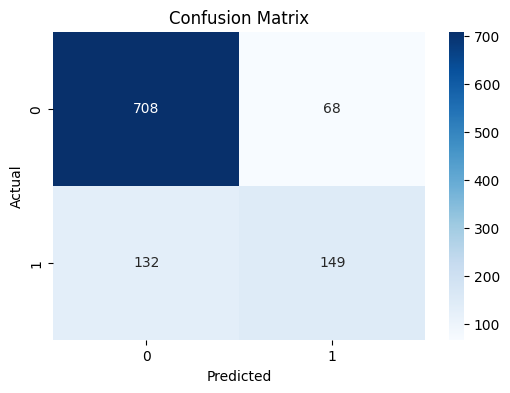

In [9]:
#We move for the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted") # Corrected label   
plt.ylabel("Actual") # Corrected label
plt.title("Confusion Matrix")
plt.show()

| Strength         | Weakness            |
| ---------------- | ------------------- |
| High TN          | High FN ❗           |
| Good AUC         | Low Recall          |
| Decent Precision | Missing churn cases |

The model performs well in identifying non-churn customers but struggles to detect churn cases effectively, as indicated by a high number of false negatives. This suggests that the model is conservative in predicting churn, which may lead to missed opportunities for customer retention.

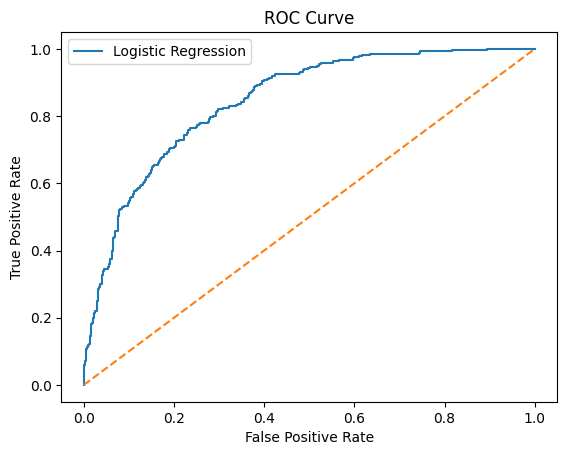

In [10]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The model demonstrates strong classification capability (AUC = 0.84), but default threshold selection leads to lower recall. Adjusting the decision threshold can improve churn detection at the cost of precision.